In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"mokshithatluri","key":"7e8532b40821952f588433177aeba26d"}'}

In [3]:
!kaggle datasets download -d altruistdelhite04/loan-prediction-problem-dataset

Dataset URL: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
License(s): unknown
100% 12.6k/12.6k [00:00<00:00, 30.2MB/s]



In [4]:
!unzip loan-prediction-problem-dataset.zip

Archive:  loan-prediction-problem-dataset.zip
  inflating: test_Y3wMUE5_7gLdaTN.csv  
  inflating: train_u6lujuX_CVtuZ9i.csv  


In [5]:
import pandas as pd

df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [8]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [22]:
df.fillna(method='ffill', inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

/tmp/ipykernel_5439/3257170757.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_5439/3257170757.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)
/tmp/ipykernel_5439/3257170757.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The 

In [23]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [24]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Logistic Regression**

In [27]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# **Decision Tree**

In [28]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# **Random Forest**

In [29]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# **Evaluation Function**

In [30]:
def evaluate_model(name, y_test, pred):

    print(f"\n{name} Performance")

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

In [31]:
evaluate_model("Logistic Regression", y_test, lr_pred)

evaluate_model("Decision Tree", y_test, dt_pred)

evaluate_model("Random Forest", y_test, rf_pred)


Logistic Regression Performance
Accuracy : 0.8130081300813008
Precision: 0.7821782178217822
Recall   : 0.9875
F1 Score : 0.8729281767955801

Decision Tree Performance
Accuracy : 0.7073170731707317
Precision: 0.775
Recall   : 0.775
F1 Score : 0.775

Random Forest Performance
Accuracy : 0.8130081300813008
Precision: 0.7878787878787878
Recall   : 0.975
F1 Score : 0.8715083798882681


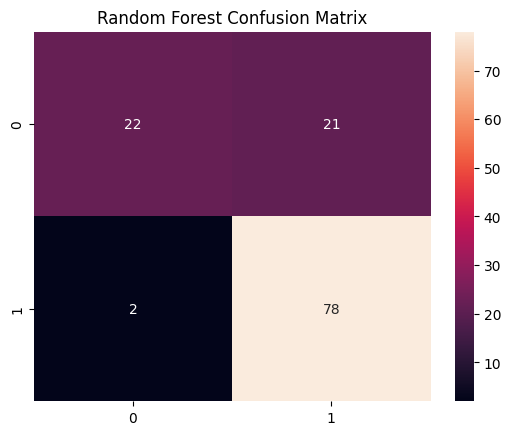

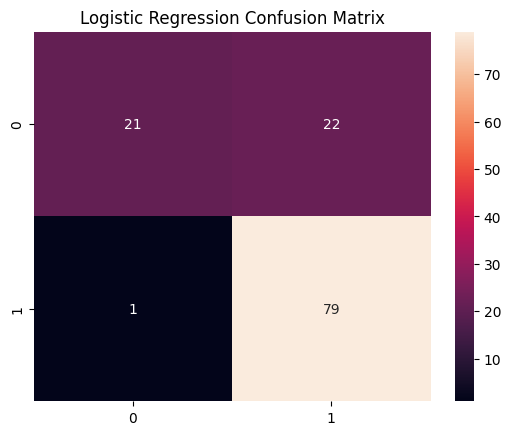

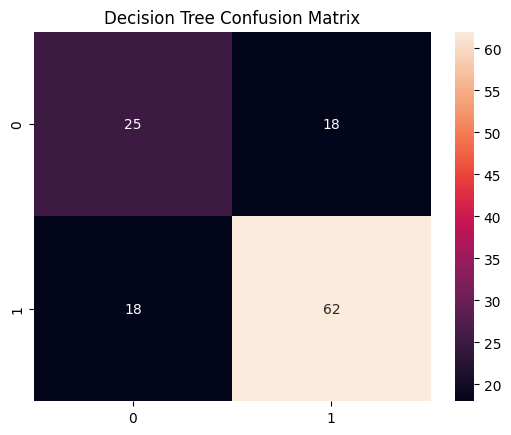

In [33]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Random Forest Confusion Matrix")

plt.show()
cm_lr = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()
cm_dt = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

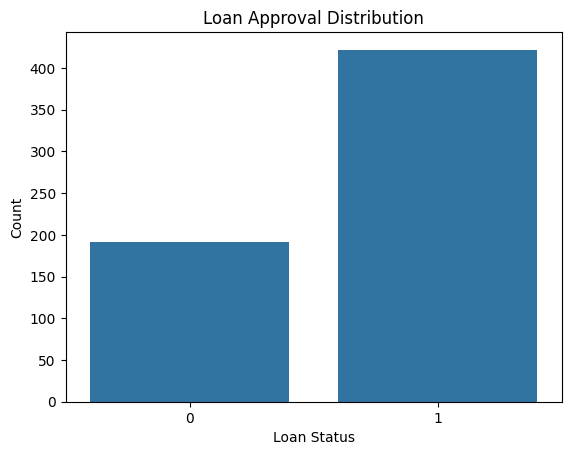

In [34]:
sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")

plt.xlabel("Loan Status")

plt.ylabel("Count")

plt.show()

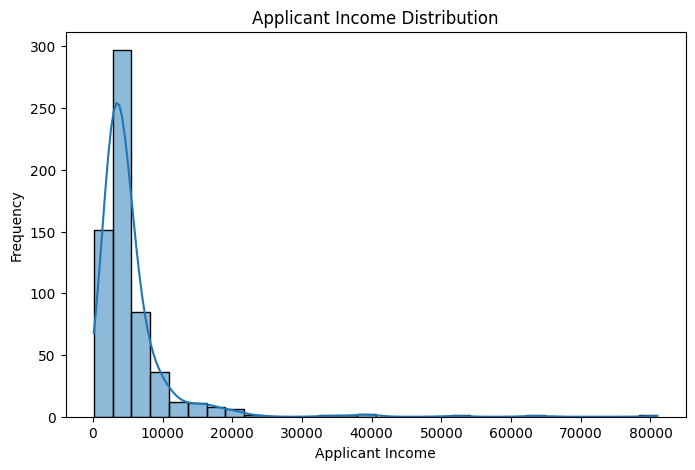

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df['ApplicantIncome'], bins=30, kde=True)

plt.title("Applicant Income Distribution")

plt.xlabel("Applicant Income")

plt.ylabel("Frequency")

plt.show()

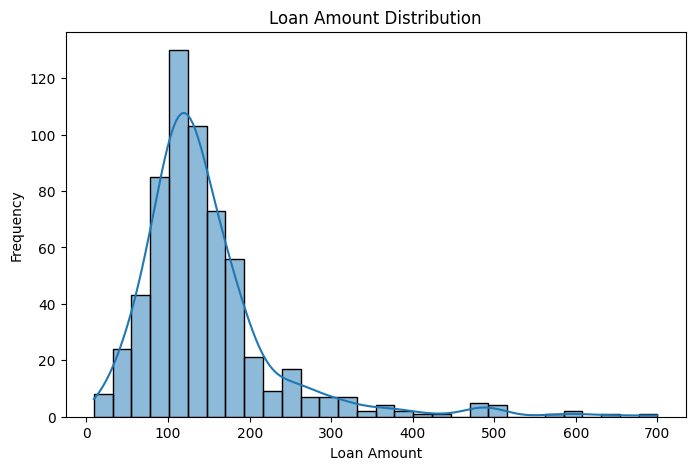

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df['LoanAmount'], bins=30, kde=True)

plt.title("Loan Amount Distribution")

plt.xlabel("Loan Amount")

plt.ylabel("Frequency")

plt.show()

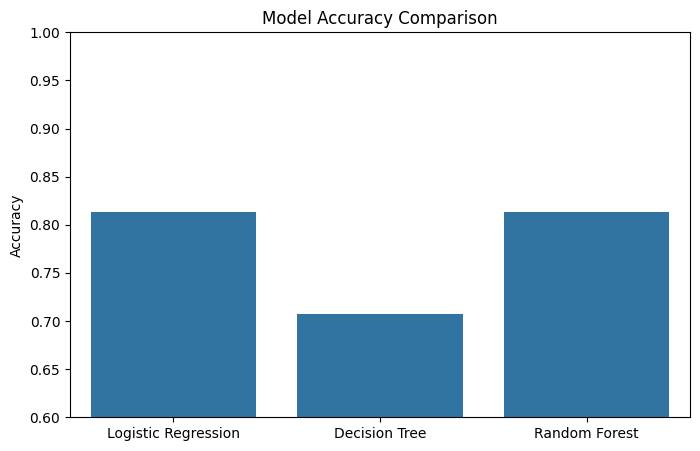

In [37]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

accuracy = [0.8130, 0.7073, 0.8130]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=accuracy)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0.6, 1.0)

plt.show()